In [1]:
import sys
sys.path.append("../DeepGeSeq/")
print(sys.path)

['/root/miniconda3/lib/python312.zip', '/root/miniconda3/lib/python3.12', '/root/miniconda3/lib/python3.12/lib-dynload', '', '/root/dgs-tutorials/lib/python3.12/site-packages', '/root/miniconda3/lib/python3.12/site-packages', '../DeepGeSeq/']


In [2]:
import h5py, os, argparse, logging, time

import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader

import DGS as dgs
from DGS.DL.Trainer import Trainer
from DGS.Model.ConvModel import CNN
from DGS.DL.Evaluator import calculate_regression_metrics

In [3]:
os.makedirs("./Log", exist_ok=True)
dgs.initialize_logger(time.strftime('./Log/log_nvtk_deepsea.%m%d.%H:%M:%S.txt'), verbosity=1)

# args
parser = argparse.ArgumentParser()
parser.add_argument("data")
parser.add_argument("--gpu-device", dest="device_id", default="0")
args = parser.parse_args(['data_MPRA/Dataset.CRE_Multi.h5', 
                          '--gpu-device', '0'])
logging.info(args)


In [4]:
## change device
os.environ["CUDA_VISIBLE_DEVICES"] = args.device_id
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Prepare dataset

1. unpack the h5file datasets
2. generate the DataLoader

In [5]:
# unpack datasets
h5file = h5py.File(args.data, 'r')
X = h5file["X"][:].swapaxes(1,-1).astype(np.float32)
Y = h5file["Y"][:].astype(np.float32)
varid = h5file["x_varid"][:].astype(str)
taskid = h5file["y_taskid"][:].astype(str)
h5file.close()

X.shape, Y.shape

((26437, 4, 87), (26437, 4))

In [6]:
Y = Y[:,:2]
taskid = taskid[:2]

In [7]:
# unpack anno
n_tasks = taskid.shape[0]
taskid

array(['CRE induced (100 uM forskolin, 5 hrs), replicate 1',
       'CRE induced (100 uM forskolin, 5 hrs), replicate 2'], dtype='<U50')

In [8]:
from sklearn.model_selection import train_test_split
train_idx, test_idx = train_test_split(range(X.shape[0]), test_size=0.2)
train_idx, val_idx = train_test_split(train_idx, test_size=0.2)
len(train_idx), len(test_idx), len(val_idx)

(16919, 5288, 4230)

In [9]:
x_train = X[train_idx]
x_val = X[test_idx]
x_test = X[val_idx]

x_train.shape, x_val.shape, x_test.shape

((16919, 4, 87), (5288, 4, 87), (4230, 4, 87))

In [10]:
y_train = Y[train_idx]
y_val = Y[test_idx]
y_test = Y[val_idx]

y_train.shape, y_val.shape, y_test.shape

((16919, 2), (5288, 2), (4230, 2))

In [11]:
# define data loader
batch_size = 5000
train_loader = DataLoader(list(zip(x_train, y_train)), batch_size=batch_size,
                            shuffle=True, num_workers=0, drop_last=False, pin_memory=True)
validate_loader = DataLoader(list(zip(x_val, y_val)), batch_size=batch_size, 
                            shuffle=False, num_workers=0, drop_last=False, pin_memory=True)
test_loader = DataLoader(list(zip(x_test, y_test)), batch_size=batch_size, 
                            shuffle=False, num_workers=0, drop_last=False, pin_memory=True)

## Define CNN model
Initialized CNN architectures in DGS

In [12]:
model = CNN(output_size=n_tasks)
model.Embedding.activation = nn.LeakyReLU(0.2)
model.Encoder.Conv.activation = nn.LeakyReLU(0.2)
model.Decoder.activation = nn.LeakyReLU(0.2)
model

CNN(
  (Embedding): BasicConvEmbed(
    (conv): Conv1d(4, 128, kernel_size=(3,), stride=(1,))
    (activation): LeakyReLU(negative_slope=0.2)
    (pool): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
  )
  (Encoder): Sequential(
    (Conv): BasicConv1d(
      (conv): Conv1d(128, 256, kernel_size=(3,), stride=(1,))
      (bn): BatchNorm1d(256, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
      (activation): LeakyReLU(negative_slope=0.2)
      (dropout): Dropout(p=0.5, inplace=False)
      (pool): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
    )
    (GAP): AdaptiveAvgPool1d(output_size=8)
    (Flatten): Flatten()
  )
  (Decoder): BasicLinearModule(
    (linear): Linear(in_features=2048, out_features=256, bias=True)
    (bn): BatchNorm1d(256, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
    (activation): LeakyReLU(negative_slope=0.2)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (Predictor): BasicPredictor(
    (Map): Linea

In [13]:
optimizer = Adam([
    {'params': model.Embedding.parameters(), 'lr': 1e-6},
    {'params': model.Encoder.parameters(), 'lr': 1e-6},
    {'params': model.Decoder.parameters(), 'lr': 1e-4},
    {'params': model.Predictor.parameters(), 'lr': 1e-4}])
criterion = nn.MSELoss().to(device)
trainer = Trainer(model, criterion, optimizer, device, patience=10)

INFO:dgs:Trainer runtime options: use_amp=False, amp_dtype=torch.float16, non_blocking=False


## Trained the model 
as an example, we only finetune the DeepSEA model architectures on TFBS sub-dataset for 10 EPOCHs.

In [14]:
# train
trainer.train(train_loader, validate_loader, epochs=40)

Epoch 0: 100%|██████████| 4/4 [00:00<00:00,  6.49it/s, loss=1.7795]
INFO:dgs:Saved checkpoint to checkpoints/best_model.pt
INFO:dgs:
Epoch: 0
Time: 0.77s
Training Loss: 1.7795
Validation Loss: 1.3878
Validation Metric: 0.0000
Best Validation Loss: 1.3878
Best Validation Metric: 0.0000
Best Epoch: 0

Epoch 1: 100%|██████████| 4/4 [00:00<00:00, 25.35it/s, loss=1.6425]
INFO:dgs:Saved checkpoint to checkpoints/best_model.pt
INFO:dgs:
Epoch: 1
Time: 0.36s
Training Loss: 1.6425
Validation Loss: 1.3742
Validation Metric: 0.0000
Best Validation Loss: 1.3742
Best Validation Metric: 0.0000
Best Epoch: 1

Epoch 2: 100%|██████████| 4/4 [00:00<00:00, 31.91it/s, loss=1.5093]
INFO:dgs:Saved checkpoint to checkpoints/best_model.pt
INFO:dgs:
Epoch: 2
Time: 0.26s
Training Loss: 1.5093
Validation Loss: 1.3633
Validation Metric: 0.0000
Best Validation Loss: 1.3633
Best Validation Metric: 0.0000
Best Epoch: 2

Epoch 3: 100%|██████████| 4/4 [00:00<00:00, 13.66it/s, loss=1.4060]
INFO:dgs:Saved checkpoint to 

TrainerMetrics(train_losses=[1.7795066237449646, 1.6425435841083527, 1.5093313455581665, 1.4060154557228088, 1.3246560096740723, 1.2591754496097565, 1.1857005953788757, 1.1506060361862183, 1.0942991077899933, 1.0602510273456573, 1.0269514620304108, 1.0063243210315704, 0.9732269644737244, 0.9518597275018692, 0.941441148519516, 0.9180404245853424, 0.9229995608329773, 0.9144732356071472], val_losses=[1.387800395488739, 1.3741627931594849, 1.363300383090973, 1.354102611541748, 1.3470871448516846, 1.342380166053772, 1.3396904468536377, 1.3388283252716064, 1.3394878506660461, 1.3416453003883362, 1.3449116945266724, 1.3488762378692627, 1.3538976907730103, 1.359933078289032, 1.3666450381278992, 1.3743589520454407, 1.3830721974372864, 1.392106294631958], train_metrics=[], val_metrics=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], best_val_loss=1.3388283252716064, best_val_metric=0.0, best_epoch=7)

In [15]:
# if you have enabled tensorboard
# !tensorboard --logdir=runs --bind_all

## Evaluated the model

In [16]:
os.makedirs("./Test", exist_ok=True)

In [17]:
# predict test-set
_, _, test_predictions, test_targets = trainer.validate(test_loader, return_predictions=True)

# metric test-set
metric = calculate_regression_metrics(test_targets, test_predictions)
metric

,mse,rmse,mae,r2,pearson_r,pearson_p,spearman_r,spearman_p,kendall_tau,kendall_p
task_0,1.616726,1.271505,1.075503,-0.152206,0.706327,0.0,0.716946,0.0,0.522775,0.0
task_1,1.158921,1.076532,0.896370,-0.061777,0.646954,0.0,0.659110,0.0,0.472812,0.0


In [18]:
# from sklearn.metrics import r2_score
from scipy.stats import pearsonr
# r2_score(test_targets[:,0], test_predictions[:,0])
# r2_score(test_targets[:,1], test_predictions[:,1])
pearsonr(test_targets[:,0], test_predictions[:,0])
# pearsonr(test_targets[:,1], test_predictions[:,1])

PearsonRResult(statistic=np.float32(0.70632684), pvalue=np.float32(0.0))

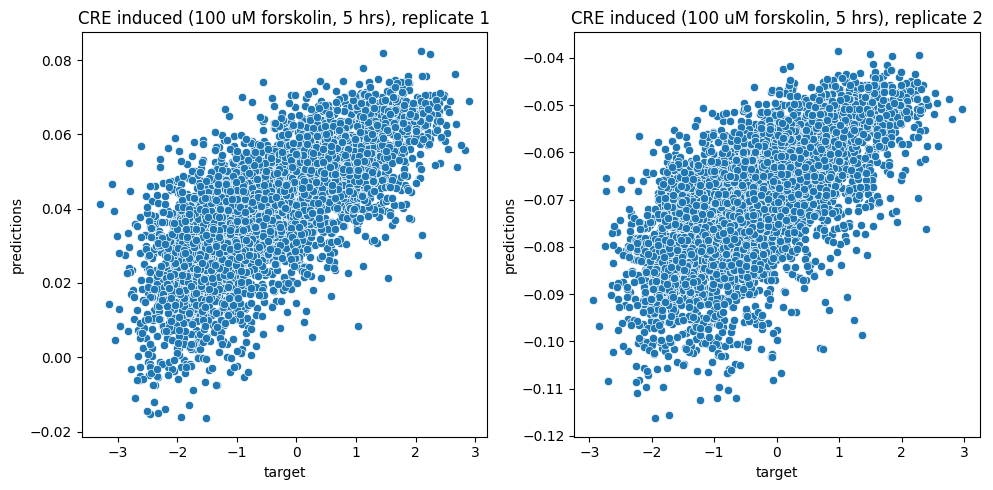

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
sns.scatterplot(x=test_targets[:,0], y=test_predictions[:,0])
plt.xlabel("target")
plt.ylabel("predictions")
plt.title(taskid[0])

plt.subplot(1,2,2)
sns.scatterplot(x=test_targets[:,1], y=test_predictions[:,1])
plt.xlabel("target")
plt.ylabel("predictions")
plt.title(taskid[1])

plt.tight_layout()
plt.savefig("Test/Scatter.pdf", bbox_inches='tight')
plt.show()

## ISM
The sequence pattern deep learning represented internally for its accurate prediction.

Note: DeepSEA architecture have NO `model.Embedding.conv layer`, which is different to the NvTK predifined models.
We calculated the first-layer convolutional layer `model.conv_net[0]` as `hook_module` instead.
And the `motif_width` could be the filter_size of DeepSEA `model.conv_net[0]`.

In [20]:
import logomaker
os.makedirs("ISM", exist_ok=True)


def _model_output_numpy(output):
    if isinstance(output, (tuple, list)):
        output = output[0]
    output = output.reshape(output.shape[0], -1)
    return output.detach().cpu().numpy()


def ism(model, X):
    """Brute-force single-base in-silico mutagenesis.

    Returns an array with shape (samples, bases, positions, tasks).
    """
    model.eval()
    X = X.to(device)
    if X.ndim != 3:
        raise ValueError(f"Expected 3D sequence tensor, got {tuple(X.shape)}")
    channel_first = X.shape[1] == 4
    if not channel_first and X.shape[2] != 4:
        raise ValueError(f"Could not find base axis of length 4 in {tuple(X.shape)}")

    with torch.no_grad():
        base_pred = _model_output_numpy(model(X))
        n_samples, n_tasks = base_pred.shape
        seq_len = X.shape[2] if channel_first else X.shape[1]
        effects = np.zeros((n_samples, 4, seq_len, n_tasks), dtype=np.float32)

        for pos in range(seq_len):
            for base in range(4):
                mutated = X.clone()
                if channel_first:
                    mutated[:, :, pos] = 0
                    mutated[:, base, pos] = 1
                else:
                    mutated[:, pos, :] = 0
                    mutated[:, pos, base] = 1
                pred = _model_output_numpy(model(mutated))
                effects[:, base, pos, :] = pred - base_pred
    return effects


def normalize_ism_score(X, target, ism_scores):
    """Collapse task-specific ISM effects into a target-weighted base score."""
    scores = np.asarray(ism_scores, dtype=np.float32)
    target_np = target.detach().cpu().numpy() if isinstance(target, torch.Tensor) else np.asarray(target)
    if scores.ndim != 4:
        raise ValueError(f"Expected 4D ISM scores, got {scores.shape}")
    weights = target_np.reshape(target_np.shape[0], 1, 1, target_np.shape[1]).astype(np.float32)
    denom = np.maximum(np.sum(np.abs(weights), axis=-1), 1e-6)
    weighted = np.sum(scores * weights, axis=-1) / denom
    return weighted.astype(np.float32)


In [21]:
ism_score, ism_score_normed = [], []

for d, t in test_loader:
    d = d.to(device)
    t = t.to(device)
    ism_s = ism(model, d)
    ism_s_n = normalize_ism_score(d, t, ism_s)
    ism_score.append(ism_s)
    ism_score_normed.append(ism_s_n)

ism_score = np.concatenate(ism_score, axis=0)
ism_score_normed = np.concatenate(ism_score_normed, axis=0)

ism_score.shape, ism_score_normed.shape

((4230, 4, 87, 2), (4230, 4, 87))

### ISM visualization and summary

The ISM tensor records how single-base substitutions change the model output. We summarize these effects across sequences to identify important positions, task-specific response patterns, and representative high-impact examples.

In [22]:
from DGS.Data.Sequence import one_hot_decode

ISM_BASES = ["A", "C", "G", "T"]


def _to_numpy(array_like):
    if isinstance(array_like, torch.Tensor):
        return array_like.detach().cpu().numpy()
    return np.asarray(array_like)


def _ensure_ism_nlbt(scores):
    """Convert ISM scores to (samples, positions, bases, tasks)."""
    scores = _to_numpy(scores)
    if scores.ndim != 4:
        raise ValueError(f"Expected 4D ISM scores, got shape {scores.shape}.")
    if scores.shape[2] == 4:
        return scores
    if scores.shape[1] == 4:
        return np.transpose(scores, (0, 2, 1, 3))
    raise ValueError(f"Could not find base axis of length 4 in shape {scores.shape}.")


def _ensure_ism_nlb(scores):
    """Convert normalized ISM scores to (samples, positions, bases)."""
    scores = _to_numpy(scores)
    if scores.ndim != 3:
        raise ValueError(f"Expected 3D normalized ISM scores, got shape {scores.shape}.")
    if scores.shape[2] == 4:
        return scores
    if scores.shape[1] == 4:
        return np.transpose(scores, (0, 2, 1))
    raise ValueError(f"Could not find base axis of length 4 in shape {scores.shape}.")


ism_scores_nlbt = _ensure_ism_nlbt(ism_score)
ism_normed_nlb = _ensure_ism_nlb(ism_score_normed)

n_ism_samples, sequence_length, _, n_ism_tasks = ism_scores_nlbt.shape
task_labels = [str(t) for t in taskid[:n_ism_tasks]]
position_labels = np.arange(sequence_length)

# Task-by-position importance: larger values indicate positions where mutations
# more strongly change the model output for that task.
ism_position_importance = np.mean(np.abs(ism_scores_nlbt), axis=(0, 2)).T
ism_position_df = pd.DataFrame(
    ism_position_importance,
    index=task_labels,
    columns=position_labels,
)

# Signed base effects averaged across sequences. This is useful for sequence logos.
ism_base_mean_by_task = np.mean(ism_scores_nlbt, axis=0)
ism_normed_mean = np.mean(ism_normed_nlb, axis=0)

ism_position_df.to_csv("ISM/ism_position_importance.tsv", sep="\t")

print("Raw ISM shape (samples, positions, bases, tasks):", ism_scores_nlbt.shape)
print("Normalized ISM shape (samples, positions, bases):", ism_normed_nlb.shape)
ism_position_df.iloc[:, :5]

Raw ISM shape (samples, positions, bases, tasks): (4230, 87, 4, 2)
Normalized ISM shape (samples, positions, bases): (4230, 87, 4)


,0,1,2,3,4
"CRE induced (100 uM forskolin, 5 hrs), replicate 1",0.000765,0.001409,0.002912,0.002543,0.002111
"CRE induced (100 uM forskolin, 5 hrs), replicate 2",0.000365,0.001260,0.001963,0.001525,0.001168


### Global position importance

The heatmap below shows the mean absolute mutation effect at each position for each MPRA task. Peaks indicate sequence positions where the model is most sensitive to base changes.

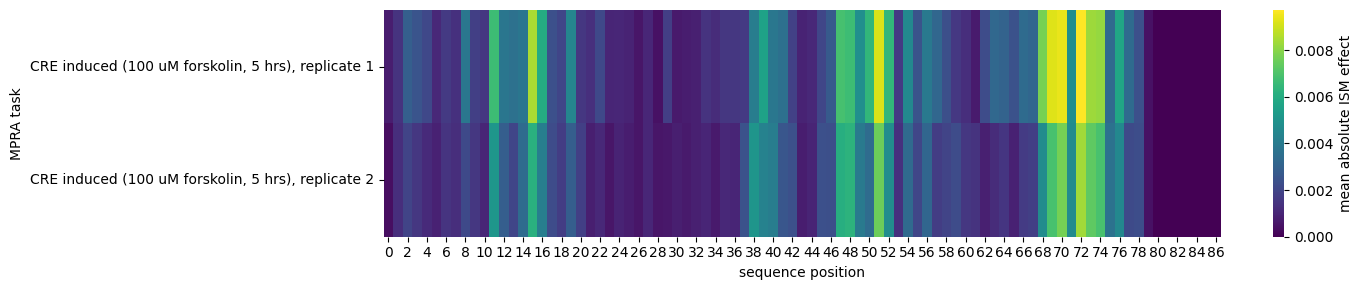

In [23]:
plt.figure(figsize=(max(10, sequence_length / 6), 2 + 0.5 * n_ism_tasks))
sns.heatmap(
    ism_position_df,
    cmap="viridis",
    cbar_kws={"label": "mean absolute ISM effect"},
)
plt.xlabel("sequence position")
plt.ylabel("MPRA task")
plt.tight_layout()
plt.savefig("ISM/ism_position_importance_heatmap.pdf", bbox_inches="tight")
plt.show()

In [24]:
top_n_positions = 10
top_position_rows = []

for task_i, task_label in enumerate(task_labels):
    top_positions = np.argsort(ism_position_importance[task_i])[::-1][:top_n_positions]
    for rank, position in enumerate(top_positions, start=1):
        base_effects = ism_base_mean_by_task[position, :, task_i]
        strongest_base_idx = int(np.argmax(np.abs(base_effects)))
        top_position_rows.append({
            "task": task_label,
            "rank": rank,
            "position": int(position),
            "mean_abs_ism": float(ism_position_importance[task_i, position]),
            "strongest_base": ISM_BASES[strongest_base_idx],
            "strongest_base_signed_effect": float(base_effects[strongest_base_idx]),
        })

ism_top_positions = pd.DataFrame(top_position_rows)
ism_top_positions.to_csv("ISM/ism_top_positions.tsv", sep="\t", index=False)
ism_top_positions

,task,rank,position,mean_abs_ism,strongest_base,strongest_base_signed_effect
0,"CRE induced (100 uM forskolin, 5 hrs), replica...",1,72,0.009723,A,-0.016876
1,"CRE induced (100 uM forskolin, 5 hrs), replica...",2,70,0.009399,A,-0.014488
2,"CRE induced (100 uM forskolin, 5 hrs), replica...",3,69,0.009244,A,-0.014426
3,"CRE induced (100 uM forskolin, 5 hrs), replica...",4,51,0.009156,A,-0.013303
4,"CRE induced (100 uM forskolin, 5 hrs), replica...",5,15,0.008489,C,-0.012024
5,"CRE induced (100 uM forskolin, 5 hrs), replica...",6,73,0.008292,A,-0.011580
6,"CRE induced (100 uM forskolin, 5 hrs), replica...",7,74,0.008167,G,-0.011507
7,"CRE induced (100 uM forskolin, 5 hrs), replica...",8,68,0.007720,A,-0.011770
8,"CRE induced (100 uM forskolin, 5 hrs), replica...",9,47,0.006847,G,-0.009945
9,"CRE induced (100 uM forskolin, 5 hrs), replica...",10,48,0.006675,A,-0.010273


### Task-specific ISM profiles

The line plot compares task-level mutation sensitivity across positions. The sequence logo uses signed base effects for one selected task, so positive and negative letters indicate bases that increase or decrease the selected model output on average.

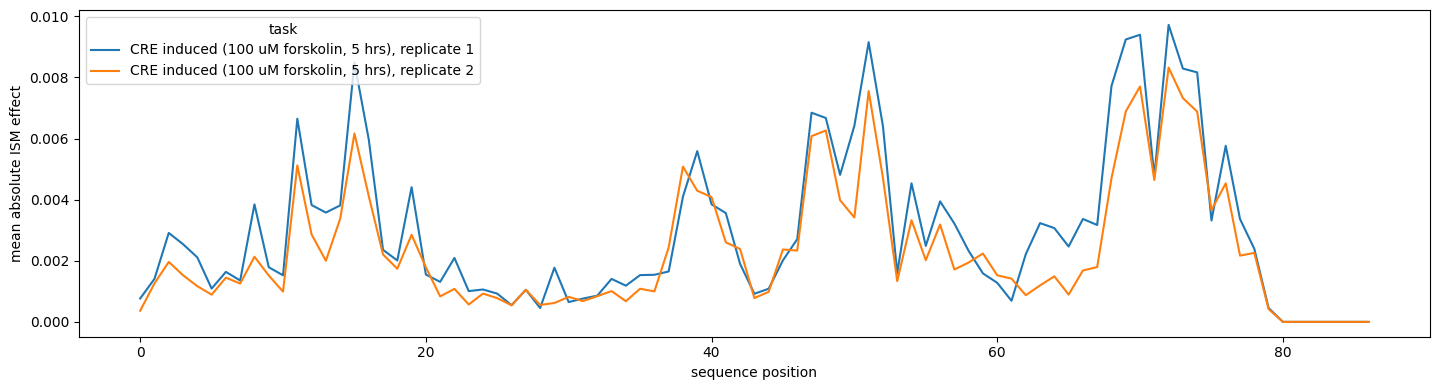

In [25]:
ism_profile_long = ism_position_df.reset_index().rename(columns={"index": "task"}).melt(
    id_vars="task",
    var_name="position",
    value_name="mean_abs_ism",
)
ism_profile_long["position"] = ism_profile_long["position"].astype(int)

plt.figure(figsize=(max(10, sequence_length / 6), 4))
sns.lineplot(data=ism_profile_long, x="position", y="mean_abs_ism", hue="task")
plt.xlabel("sequence position")
plt.ylabel("mean absolute ISM effect")
plt.tight_layout()
plt.savefig("ISM/ism_position_profiles.pdf", bbox_inches="tight")
plt.show()

<Figure size 1740x300 with 0 Axes>

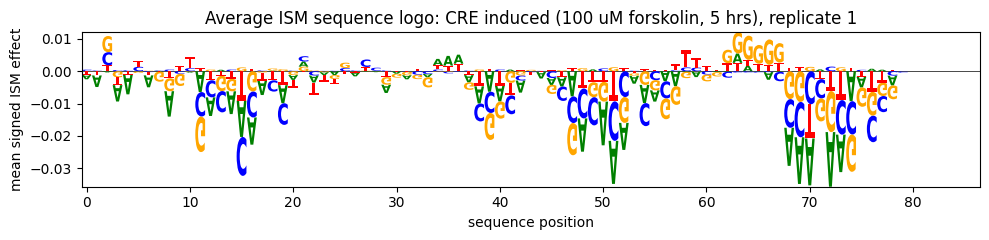

In [26]:
ism_logo_task_index = 0
ism_logo_task_label = task_labels[ism_logo_task_index]
logo_matrix = pd.DataFrame(
    ism_base_mean_by_task[:, :, ism_logo_task_index],
    columns=ISM_BASES,
)

plt.figure(figsize=(max(12, sequence_length / 5), 3))
logo = logomaker.Logo(logo_matrix, center_values=False)
logo.ax.set_xlabel("sequence position")
logo.ax.set_ylabel("mean signed ISM effect")
logo.ax.set_title(f"Average ISM sequence logo: {ism_logo_task_label}")
plt.tight_layout()
plt.savefig("ISM/ism_average_logo_task0.pdf", bbox_inches="tight")
plt.show()

### High-impact examples

The next cells select sequences with the strongest mean absolute ISM effect for one task. These examples are useful for inspecting whether high-impact sequences share similar base preferences or motif-like patterns.

In [27]:
top_k_ism_sequences = min(20, n_ism_samples)
sequence_ism_strength = np.mean(
    np.abs(ism_scores_nlbt[:, :, :, ism_logo_task_index]),
    axis=(1, 2),
)
top_ism_sequence_idx = np.argsort(sequence_ism_strength)[::-1][:top_k_ism_sequences].copy()

top_ism_summary = pd.DataFrame({
    "rank": np.arange(1, top_k_ism_sequences + 1),
    "sample_index": top_ism_sequence_idx,
    "mean_abs_ism": sequence_ism_strength[top_ism_sequence_idx],
})

if "test_predictions" in globals() and test_predictions.shape[1] > ism_logo_task_index:
    top_ism_summary["prediction"] = test_predictions[top_ism_sequence_idx, ism_logo_task_index]
if "test_targets" in globals() and test_targets.shape[1] > ism_logo_task_index:
    top_ism_summary["target"] = test_targets[top_ism_sequence_idx, ism_logo_task_index]
if "x_test" in globals():
    top_ism_summary["sequence"] = [
        one_hot_decode(x_test[idx].transpose(1, 0), include_n=False)
        for idx in top_ism_sequence_idx
    ]

top_ism_summary.to_csv("ISM/ism_high_impact_sequences.tsv", sep="\t", index=False)
top_ism_summary

,rank,sample_index,mean_abs_ism,prediction,target,sequence
0,1,2153,0.003491,0.064225,1.901803,GCACCTGACAATGACGTCAGCTGCCAGATCCCATGGCCGTCAGACT...
1,2,2673,0.003488,0.058695,1.362778,GAACAAGACAGTGACGTCAGCTGCCAGATCCCATGGCCGTCATAAT...
2,3,581,0.003469,0.055255,1.304978,GCACCAGACAGTGACGTCAACTGCTAGATCTCATGGCCGTCAGACT...
3,4,3062,0.003465,0.065824,2.129217,GAACCAGACAGTGACGTCGGCAGCCAGATCCCATGCCCGTCATACT...
4,5,3925,0.003451,0.050821,0.783666,GCTCCAGACAGTGACGTCAGCTGCCAGATCCCGTGGCCGTCATAAT...
5,6,3535,0.003451,0.067630,1.020342,GCTCCAGACAGTGACGTCAGCTGCCAGCTCTCTTGGCTGTCATGCT...
6,7,2548,0.003449,0.063592,2.125221,GCGCCAGACGGTGACGTCAGCTGCCAGATCACATGGCCGTCATACT...
7,8,1504,0.003448,0.064946,1.696662,GCACCAGACAGTGACGTCAGCTGCCAAATCCCATGGCCGTCATAAT...
8,9,1141,0.003447,0.047096,0.209890,GCATCAGACAGTGACGTCAGCTGCCAGATTCGAGGGACGTCATACT...
9,10,3061,0.003441,0.066293,1.617016,GCACCAGACAGTGACGTCAGCTGCCGGATCTCATTGCCGTCATACT...


<Figure size 1740x300 with 0 Axes>

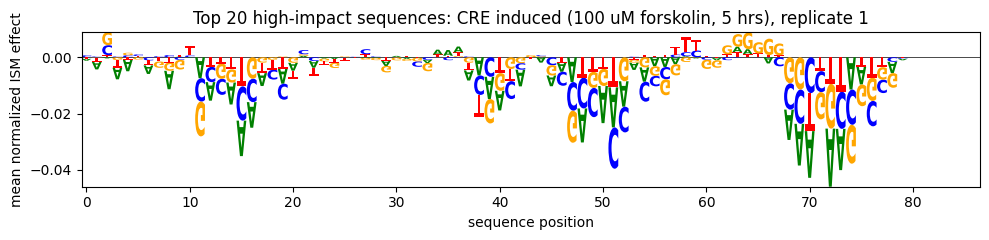

In [28]:
top_logo_matrix = pd.DataFrame(
    np.mean(ism_normed_nlb[top_ism_sequence_idx], axis=0),
    columns=ISM_BASES,
)

plt.figure(figsize=(max(12, sequence_length / 5), 3))
top_logo = logomaker.Logo(top_logo_matrix, center_values=False)
top_logo.ax.set_xlabel("sequence position")
top_logo.ax.set_ylabel("mean normalized ISM effect")
top_logo.ax.set_title(f"Top {top_k_ism_sequences} high-impact sequences: {ism_logo_task_label}")
plt.tight_layout()
plt.savefig("ISM/ism_high_impact_logo_task0.pdf", bbox_inches="tight")
plt.show()

### Interpretation notes

- Positions with high mean absolute ISM effects are model-sensitive sites and are good candidates for motif-level inspection.
- Positive signed effects indicate bases that tend to increase the selected model output; negative effects indicate bases that tend to reduce it.
- Compare the global heatmap, task-specific profile, and top-sequence logo before using these patterns for sequence design.

## In silico sequence design

After training and interpreting the MPRA activity predictor, we can use the model as an objective function for sequence design. The examples below optimize one candidate sequence toward a selected MPRA output task.

Designed sequences should be treated as model-guided hypotheses for downstream prioritization, not as experimentally validated regulatory elements.

In [29]:
from DGS.DL.Design import gradient_ascent_sequence_design, greedy_ism_sequence_design
from DGS.Data.Sequence import one_hot_decode

os.makedirs("Design", exist_ok=True)

### Select a seed sequence and target task

Here we start from one held-out MPRA sequence and maximize one selected output task. Change `design_task_index` to optimize another MPRA readout.

In [30]:
design_task_index = 0
design_seed_index = 0

initial_one_hot = torch.as_tensor(
    x_test[design_seed_index:design_seed_index + 1],
    dtype=torch.float32,
)
initial_sequence = one_hot_decode(
    initial_one_hot[0].transpose(0, 1).numpy(),
    include_n=False,
)

print("Target task:", taskid[design_task_index])
print("Seed sequence length:", len(initial_sequence))
print("Seed sequence:", initial_sequence)

Target task: CRE induced (100 uM forskolin, 5 hrs), replicate 1
Seed sequence length: 87
Seed sequence: ACACCAGGCCGTGACGACAGCTGCCAGATCCCGTGTCCGTTATGCTGTGACTTCTTGCAGACACACCATTGACGTTGATGGGATAAC


In [31]:
def predict_design_score(sequence_tensor, output_index=design_task_index):
    """Return the selected model output for one designed sequence."""
    model.eval()
    with torch.no_grad():
        output = model(sequence_tensor.to(device))
        if isinstance(output, (tuple, list)):
            output = output[0]
        output = output.reshape(output.shape[0], -1)
    return float(output[:, output_index].mean().detach().cpu())


initial_score = predict_design_score(initial_one_hot)
initial_score

0.021904021501541138

### Optimize with differentiable sequence design

`gradient_ascent_sequence_design` relaxes the sequence to soft one-hot logits during optimization, then returns a discrete sequence. The small step count keeps this tutorial quick; increase it for a stronger design run.

In [32]:
design_steps = 50
design_lr = 0.1

gradient_result = gradient_ascent_sequence_design(
    model,
    initial_one_hot,
    output_index=design_task_index,
    steps=design_steps,
    lr=design_lr,
    temperature=1.0,
    device=device,
    seed=0,
)

print("Gradient-designed score:", gradient_result.score)
print("Gradient-designed sequence:", gradient_result.sequence)

Gradient-designed score: 0.11999769508838654
Gradient-designed sequence: CGCCCTCACTATGACGTCGGCAGGCCGCCCGCTCGACCGTCATGATGTGACGTCTTTCTTTTTATGGGTTGACGTCAATGGGATAAC


### Refine with greedy ISM design

The greedy ISM step evaluates discrete single-base substitutions and keeps improving mutations. This is slower than the gradient step, so the default `max_steps` is intentionally small.

In [33]:
design_greedy_steps = 5

greedy_result = greedy_ism_sequence_design(
    model,
    gradient_result.one_hot,
    output_index=design_task_index,
    max_steps=design_greedy_steps,
    device=device,
)

print("Greedy-refined score:", greedy_result.score)
print("Greedy-refined sequence:", greedy_result.sequence)

Greedy-refined score: 0.12356701493263245
Greedy-refined sequence: CGCCCTCACTATGACGTCGGCAGGCCGCCCCCTTGAACGTCATGATGTGACGTCTTTCTTATGATGGGTTGACGTCAATGGGATAAC


### Compare scores and save designed candidates

The table records the initial sequence, the gradient-designed sequence, and the greedy-refined sequence. The score is the selected MPRA output predicted by the trained model.

In [34]:
design_summary = pd.DataFrame([
    {
        "stage": "initial",
        "task": taskid[design_task_index],
        "score": initial_score,
        "sequence": initial_sequence,
    },
    {
        "stage": "gradient_ascent",
        "task": taskid[design_task_index],
        "score": gradient_result.score,
        "sequence": gradient_result.sequence,
    },
    {
        "stage": "greedy_ism",
        "task": taskid[design_task_index],
        "score": greedy_result.score,
        "sequence": greedy_result.sequence,
    },
])

design_summary.to_csv("Design/design_sequences.tsv", sep="\t", index=False)
design_summary

,stage,task,score,sequence
0,initial,"CRE induced (100 uM forskolin, 5 hrs), replica...",0.021904,ACACCAGGCCGTGACGACAGCTGCCAGATCCCGTGTCCGTTATGCT...
1,gradient_ascent,"CRE induced (100 uM forskolin, 5 hrs), replica...",0.119998,CGCCCTCACTATGACGTCGGCAGGCCGCCCGCTCGACCGTCATGAT...
2,greedy_ism,"CRE induced (100 uM forskolin, 5 hrs), replica...",0.123567,CGCCCTCACTATGACGTCGGCAGGCCGCCCCCTTGAACGTCATGAT...


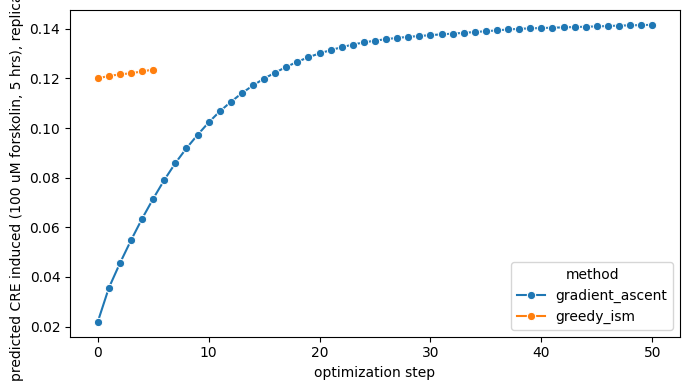

In [35]:
gradient_history = pd.DataFrame(gradient_result.history).assign(method="gradient_ascent")
greedy_history = pd.DataFrame(greedy_result.history).assign(method="greedy_ism")
design_history = pd.concat([gradient_history, greedy_history], ignore_index=True, sort=False)

plt.figure(figsize=(7, 4))
sns.lineplot(data=design_history, x="step", y="score", hue="method", marker="o")
plt.xlabel("optimization step")
plt.ylabel(f"predicted {taskid[design_task_index]}")
plt.tight_layout()
plt.savefig("Design/design_score_history.pdf", bbox_inches="tight")
plt.show()

### Optional extensions

- Set `design_task_index = 1` to optimize the other MPRA output.
- Start from `"N" * sequence_length` or another custom sequence to test de novo design.
- Pass a custom `objective_fn` to optimize multi-task objectives, such as increasing one MPRA task while penalizing another.

## Analyzing designed sequences

Designed sequences should be analyzed as model-derived hypotheses. A practical analysis order is:

1. Confirm that the target-task prediction increased relative to the seed sequence.
2. Check whether non-target MPRA outputs also changed, because a strong design can be non-specific.
3. Inspect how many bases changed and where the mutations occurred.
4. Check simple sequence properties such as GC content and homopolymer length to avoid unrealistic candidates.
5. Revisit motif-level evidence, such as CREB-like motif distance and optional ISM profiles on the designed sequences.

The code below creates lightweight summary tables and plots for these checks.

In [36]:
from DGS.Data.Sequence import one_hot_encode


def sequence_to_ncl(sequence):
    """Convert a DNA sequence string to model input shape (1, 4, length)."""
    encoded = one_hot_encode(sequence)
    return torch.as_tensor(encoded, dtype=torch.float32).transpose(0, 1).unsqueeze(0)


def predict_all_outputs(sequences):
    inputs = torch.cat([sequence_to_ncl(seq) for seq in sequences], dim=0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(inputs)
        if isinstance(output, (tuple, list)):
            output = output[0]
        output = output.reshape(output.shape[0], -1)
    return output.detach().cpu().numpy()


def gc_content(sequence):
    sequence = sequence.upper()
    return (sequence.count("G") + sequence.count("C")) / max(len(sequence), 1)


def max_homopolymer_length(sequence):
    longest = 0
    current = 0
    previous = None
    for base in sequence.upper():
        current = current + 1 if base == previous else 1
        longest = max(longest, current)
        previous = base
    return longest


def hamming_distance_with_length_penalty(reference, candidate):
    shared = sum(a != b for a, b in zip(reference, candidate))
    return shared + abs(len(reference) - len(candidate))


candidate_sequences = design_summary["sequence"].tolist()
candidate_stages = design_summary["stage"].tolist()
reference_sequence = design_summary.loc[design_summary["stage"] == "initial", "sequence"].iloc[0]

candidate_output = predict_all_outputs(candidate_sequences)
candidate_task_labels = [str(t) for t in taskid[:candidate_output.shape[1]]]
candidate_prediction_df = pd.DataFrame(
    candidate_output,
    columns=[f"pred_task_{i}" for i in range(candidate_output.shape[1])],
)
candidate_prediction_df.insert(0, "stage", candidate_stages)

candidate_analysis = design_summary[["stage", "task", "score", "sequence"]].copy()
candidate_analysis["length"] = candidate_analysis["sequence"].str.len()
candidate_analysis["gc_content"] = candidate_analysis["sequence"].map(gc_content)
candidate_analysis["max_homopolymer"] = candidate_analysis["sequence"].map(max_homopolymer_length)
candidate_analysis["n_mutations_vs_initial"] = candidate_analysis["sequence"].map(
    lambda seq: hamming_distance_with_length_penalty(reference_sequence, seq)
)
candidate_analysis["mutation_fraction_vs_initial"] = (
    candidate_analysis["n_mutations_vs_initial"] / candidate_analysis["length"].clip(lower=1)
)
candidate_analysis = candidate_analysis.merge(candidate_prediction_df, on="stage")

target_prediction_column = f"pred_task_{design_task_index}"
initial_target_prediction = candidate_analysis.loc[
    candidate_analysis["stage"] == "initial",
    target_prediction_column,
].iloc[0]
candidate_analysis["target_delta_vs_initial"] = (
    candidate_analysis[target_prediction_column] - initial_target_prediction
)

candidate_analysis.to_csv("Design/design_candidate_analysis.tsv", sep="\t", index=False)
candidate_analysis

,stage,task,score,sequence,length,gc_content,max_homopolymer,n_mutations_vs_initial,mutation_fraction_vs_initial,pred_task_0,pred_task_1,target_delta_vs_initial
0,initial,"CRE induced (100 uM forskolin, 5 hrs), replica...",0.021904,ACACCAGGCCGTGACGACAGCTGCCAGATCCCGTGTCCGTTATGCT...,87,0.540230,3,0,0.000000,0.021904,-0.078976,0.000000
1,gradient_ascent,"CRE induced (100 uM forskolin, 5 hrs), replica...",0.119998,CGCCCTCACTATGACGTCGGCAGGCCGCCCGCTCGACCGTCATGAT...,87,0.551724,5,35,0.402299,0.119998,-0.030778,0.098094
2,greedy_ism,"CRE induced (100 uM forskolin, 5 hrs), replica...",0.123567,CGCCCTCACTATGACGTCGGCAGGCCGCCCCCTTGAACGTCATGAT...,87,0.540230,5,33,0.379310,0.123567,-0.030421,0.101663


### Prediction specificity across tasks

A good designed sequence should improve the intended MPRA output, but it is also useful to inspect whether other outputs changed. If a non-target task increases or decreases strongly, the design may be optimizing a broad activity signal rather than a task-specific regulatory pattern.

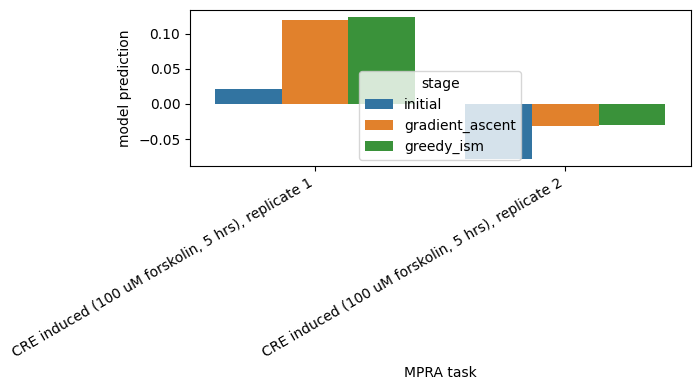

,stage,task_index,prediction,task
0,initial,0,0.021904,"CRE induced (100 uM forskolin, 5 hrs), replica..."
1,gradient_ascent,0,0.119998,"CRE induced (100 uM forskolin, 5 hrs), replica..."
2,greedy_ism,0,0.123567,"CRE induced (100 uM forskolin, 5 hrs), replica..."
3,initial,1,-0.078976,"CRE induced (100 uM forskolin, 5 hrs), replica..."
4,gradient_ascent,1,-0.030778,"CRE induced (100 uM forskolin, 5 hrs), replica..."
5,greedy_ism,1,-0.030421,"CRE induced (100 uM forskolin, 5 hrs), replica..."


In [37]:
prediction_long = candidate_prediction_df.melt(
    id_vars="stage",
    var_name="task_index",
    value_name="prediction",
)
prediction_long["task_index"] = prediction_long["task_index"].str.replace("pred_task_", "", regex=False).astype(int)
prediction_long["task"] = prediction_long["task_index"].map(lambda i: candidate_task_labels[i])
prediction_long.to_csv("Design/design_predictions_by_task.tsv", sep="\t", index=False)

plt.figure(figsize=(max(7, 2.5 * len(candidate_task_labels)), 4))
sns.barplot(data=prediction_long, x="task", y="prediction", hue="stage")
plt.xticks(rotation=30, ha="right")
plt.xlabel("MPRA task")
plt.ylabel("model prediction")
plt.tight_layout()
plt.savefig("Design/design_predictions_by_task.pdf", bbox_inches="tight")
plt.show()

prediction_long

### Mutation map relative to the seed sequence

This table and heatmap show which bases were changed by the design process. For MPRA follow-up, candidates with extreme numbers of edits or long artificial repeats should be treated cautiously even if the model score is high.

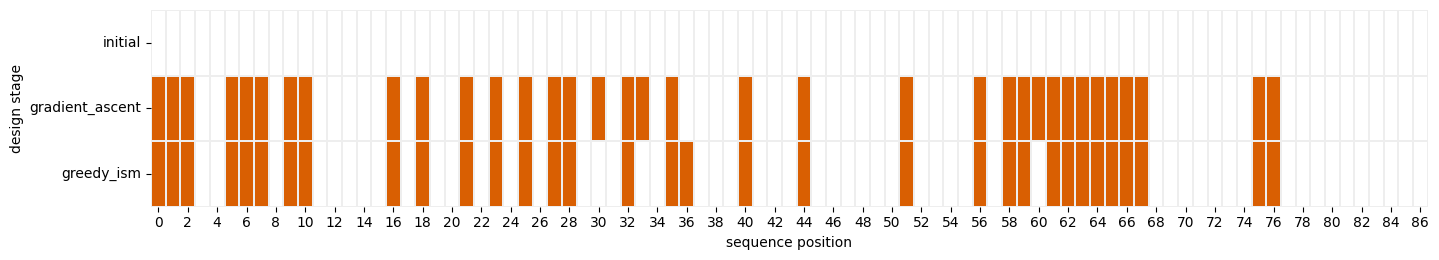

,stage,position,reference_base,designed_base
0,gradient_ascent,0,A,C
1,gradient_ascent,1,C,G
2,gradient_ascent,2,A,C
3,gradient_ascent,5,A,T
4,gradient_ascent,6,G,C
5,gradient_ascent,7,G,A
6,gradient_ascent,9,C,T
7,gradient_ascent,10,G,A
8,gradient_ascent,16,A,T
9,gradient_ascent,18,A,G


In [38]:
mutation_rows = []
mutation_matrix_rows = []

for _, row in design_summary.iterrows():
    stage = row["stage"]
    sequence = row["sequence"]
    changed = []
    for position, (ref_base, alt_base) in enumerate(zip(reference_sequence, sequence)):
        is_changed = ref_base != alt_base
        changed.append(int(is_changed))
        if stage != "initial" and is_changed:
            mutation_rows.append({
                "stage": stage,
                "position": position,
                "reference_base": ref_base,
                "designed_base": alt_base,
            })
    mutation_matrix_rows.append(pd.Series(changed, name=stage))

design_mutations = pd.DataFrame(mutation_rows)
design_mutations.to_csv("Design/design_mutations_vs_initial.tsv", sep="\t", index=False)

mutation_matrix = pd.DataFrame(mutation_matrix_rows)
plt.figure(figsize=(max(10, len(reference_sequence) / 6), 1.5 + 0.4 * len(mutation_matrix)))
sns.heatmap(
    mutation_matrix,
    cmap=["white", "#d95f02"],
    cbar=False,
    linewidths=0.1,
    linecolor="#eeeeee",
)
plt.xlabel("sequence position")
plt.ylabel("design stage")
plt.tight_layout()
plt.savefig("Design/design_mutation_map.pdf", bbox_inches="tight")
plt.show()

design_mutations.head(20)

### CREB-like motif check

Because this MPRA example is based on cAMP-responsive enhancer activity, a simple sanity check is whether designed sequences move closer to a CREB-like motif. This is only a lightweight motif check; for final interpretation, use a proper motif database scan such as TomTom/FIMO or the motif workflow used elsewhere in DGS.

In [39]:
def reverse_complement(sequence):
    table = str.maketrans("ACGTNacgtn", "TGCANtgcan")
    return sequence.translate(table)[::-1]


def min_motif_hamming_distance(sequence, motif):
    sequence = sequence.upper()
    motifs = [motif.upper(), reverse_complement(motif).upper()]
    best_distance = len(motif)
    best_position = None
    best_motif = None
    for motif_seq in motifs:
        for start in range(0, len(sequence) - len(motif_seq) + 1):
            window = sequence[start:start + len(motif_seq)]
            distance = sum(a != b for a, b in zip(window, motif_seq))
            if distance < best_distance:
                best_distance = distance
                best_position = start
                best_motif = motif_seq
    return best_distance, best_position, best_motif


creb_consensus = "TGACGTCA"
motif_rows = []
for _, row in design_summary.iterrows():
    distance, position, motif_orientation = min_motif_hamming_distance(row["sequence"], creb_consensus)
    motif_rows.append({
        "stage": row["stage"],
        "motif": creb_consensus,
        "min_hamming_distance": distance,
        "best_position": position,
        "matched_orientation": motif_orientation,
    })

design_motif_check = pd.DataFrame(motif_rows)
design_motif_check.to_csv("Design/design_creb_motif_check.tsv", sep="\t", index=False)
design_motif_check

,stage,motif,min_hamming_distance,best_position,matched_orientation
0,initial,TGACGTCA,1,11,TGACGTCA
1,gradient_ascent,TGACGTCA,0,69,TGACGTCA
2,greedy_ism,TGACGTCA,0,69,TGACGTCA


### Optional: re-run ISM on designed candidates

If the designed sequence has a higher prediction, the next question is whether the sensitivity pattern looks biologically plausible. Re-running ISM on only the candidate sequences is much cheaper than running it on the full test set and can reveal whether the optimized score is concentrated around motif-like positions or spread across many bases.

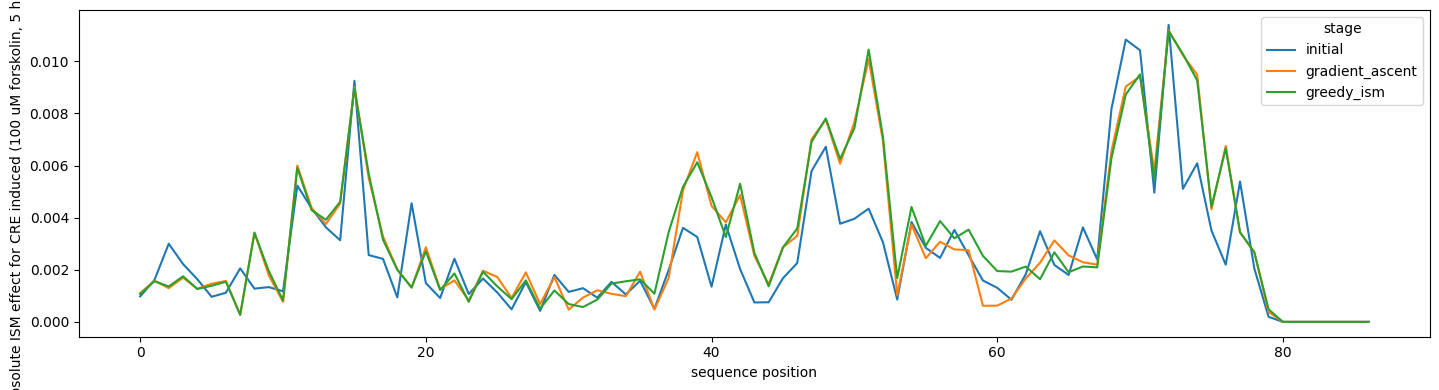

In [40]:
if "ism" not in globals():
    print("Run the ISM cells first, or import the ISM function, before this optional analysis.")
else:
    if "_to_numpy" not in globals():
        def _to_numpy(array_like):
            if isinstance(array_like, torch.Tensor):
                return array_like.detach().cpu().numpy()
            return np.asarray(array_like)

    if "_ensure_ism_nlbt" not in globals():
        def _ensure_ism_nlbt(scores):
            scores = _to_numpy(scores)
            if scores.ndim != 4:
                raise ValueError(f"Expected 4D ISM scores, got shape {scores.shape}.")
            if scores.shape[2] == 4:
                return scores
            if scores.shape[1] == 4:
                return np.transpose(scores, (0, 2, 1, 3))
            raise ValueError(f"Could not find base axis of length 4 in shape {scores.shape}.")

    candidate_ism_arrays = []
    for sequence in candidate_sequences:
        candidate_input = sequence_to_ncl(sequence).to(device)
        candidate_ism_arrays.append(_to_numpy(ism(model, candidate_input)))

    candidate_ism = np.concatenate(candidate_ism_arrays, axis=0)
    candidate_ism_nlbt = _ensure_ism_nlbt(candidate_ism)
    candidate_ism_profile = np.mean(
        np.abs(candidate_ism_nlbt[:, :, :, design_task_index]),
        axis=2,
    )
    candidate_ism_profile_df = pd.DataFrame(
        candidate_ism_profile,
        index=candidate_stages,
    )
    candidate_ism_profile_df.to_csv("Design/design_candidate_ism_profile.tsv", sep="\t")

    candidate_ism_long = candidate_ism_profile_df.reset_index().rename(columns={"index": "stage"}).melt(
        id_vars="stage",
        var_name="position",
        value_name="mean_abs_ism",
    )
    candidate_ism_long["position"] = candidate_ism_long["position"].astype(int)

    plt.figure(figsize=(max(10, candidate_ism_profile.shape[1] / 6), 4))
    sns.lineplot(data=candidate_ism_long, x="position", y="mean_abs_ism", hue="stage")
    plt.xlabel("sequence position")
    plt.ylabel(f"mean absolute ISM effect for {taskid[design_task_index]}")
    plt.tight_layout()
    plt.savefig("Design/design_candidate_ism_profile.pdf", bbox_inches="tight")
    plt.show()

    candidate_ism_profile_df

### How to prioritize candidates

Use the designed sequences for prioritization only when several checks agree:

- The target-task prediction increases compared with the seed.
- Non-target tasks do not show an unwanted large shift.
- The sequence does not gain unrealistic GC content or long homopolymers.
- Mutations cluster near interpretable motif-like positions rather than being scattered everywhere.
- Optional ISM profiles still support a clear regulatory pattern.

The final output of this section is a short candidate table for downstream review, not proof that the designed sequence functions in cells.